# 02 — IC / ICIR Analysis

**Purpose**: Visualise the feature information coefficient (IC) and IC Information Ratio (ICIR) across all three return horizons, and examine factor decay.

Prerequisite: run `scripts/factor_research.py` first to generate `reports/factor_research_{1y,3y,5y}.csv`.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

horizons = ['1y', '3y', '5y']
reports = {h: ROOT / 'reports' / f'factor_research_{h}.csv' for h in horizons}
dfs = {}
for h, path in reports.items():
    if path.exists():
        dfs[h] = pd.read_csv(path)
        print(f'{h}: {len(dfs[h])} features loaded from {path.name}')
    else:
        print(f'MISSING: {path} — run scripts/factor_research.py')

1y: 207 features loaded from factor_research_1y.csv
3y: 206 features loaded from factor_research_3y.csv
5y: 204 features loaded from factor_research_5y.csv


## 1 — Top features by |ICIR| (all horizons)

In [2]:
for h, df in dfs.items():
    if 'icir' not in df.columns:
        continue
    top = df.sort_values('icir', key=abs, ascending=False).head(20)
    print(f'\n--- {h} horizon: top 20 by |ICIR| ---')
    print(top[['feature', 'mean_ic', 'std_ic', 'icir', 'n_years', 'pct_positive_ic']].to_string(index=False))


--- 1y horizon: top 20 by |ICIR| ---
              feature  mean_ic  std_ic    icir  n_years  pct_positive_ic
           ev_revenue -0.16042 0.08321 -1.9280       17            0.000
             ps_ratio -0.16020 0.09413 -1.7018       17            0.000
       sales_to_price  0.16018 0.09414  1.7015       17            1.000
       altman_z_score  0.09966 0.05953  1.6740       17            0.941
                  fcf  0.15306 0.09428  1.6234        5            0.800
 quality_in_recession  0.18070 0.11457  1.5772        3            1.000
   value_in_recession  0.18609 0.12068  1.5420        3            1.000
            recession  0.19123 0.12827  1.4909        3            1.000
      value_composite  0.18888 0.12698  1.4874       17            0.941
  ps_ratio_sector_pct -0.14690 0.10267 -1.4308       17            0.118
   value_in_high_rate  0.13787 0.09849  1.3999        6            1.000
net_income_growth_yoy  0.06836 0.04905  1.3938       16            0.875
        ocf_t

## 2 — ICIR bar chart (top 30 per horizon)

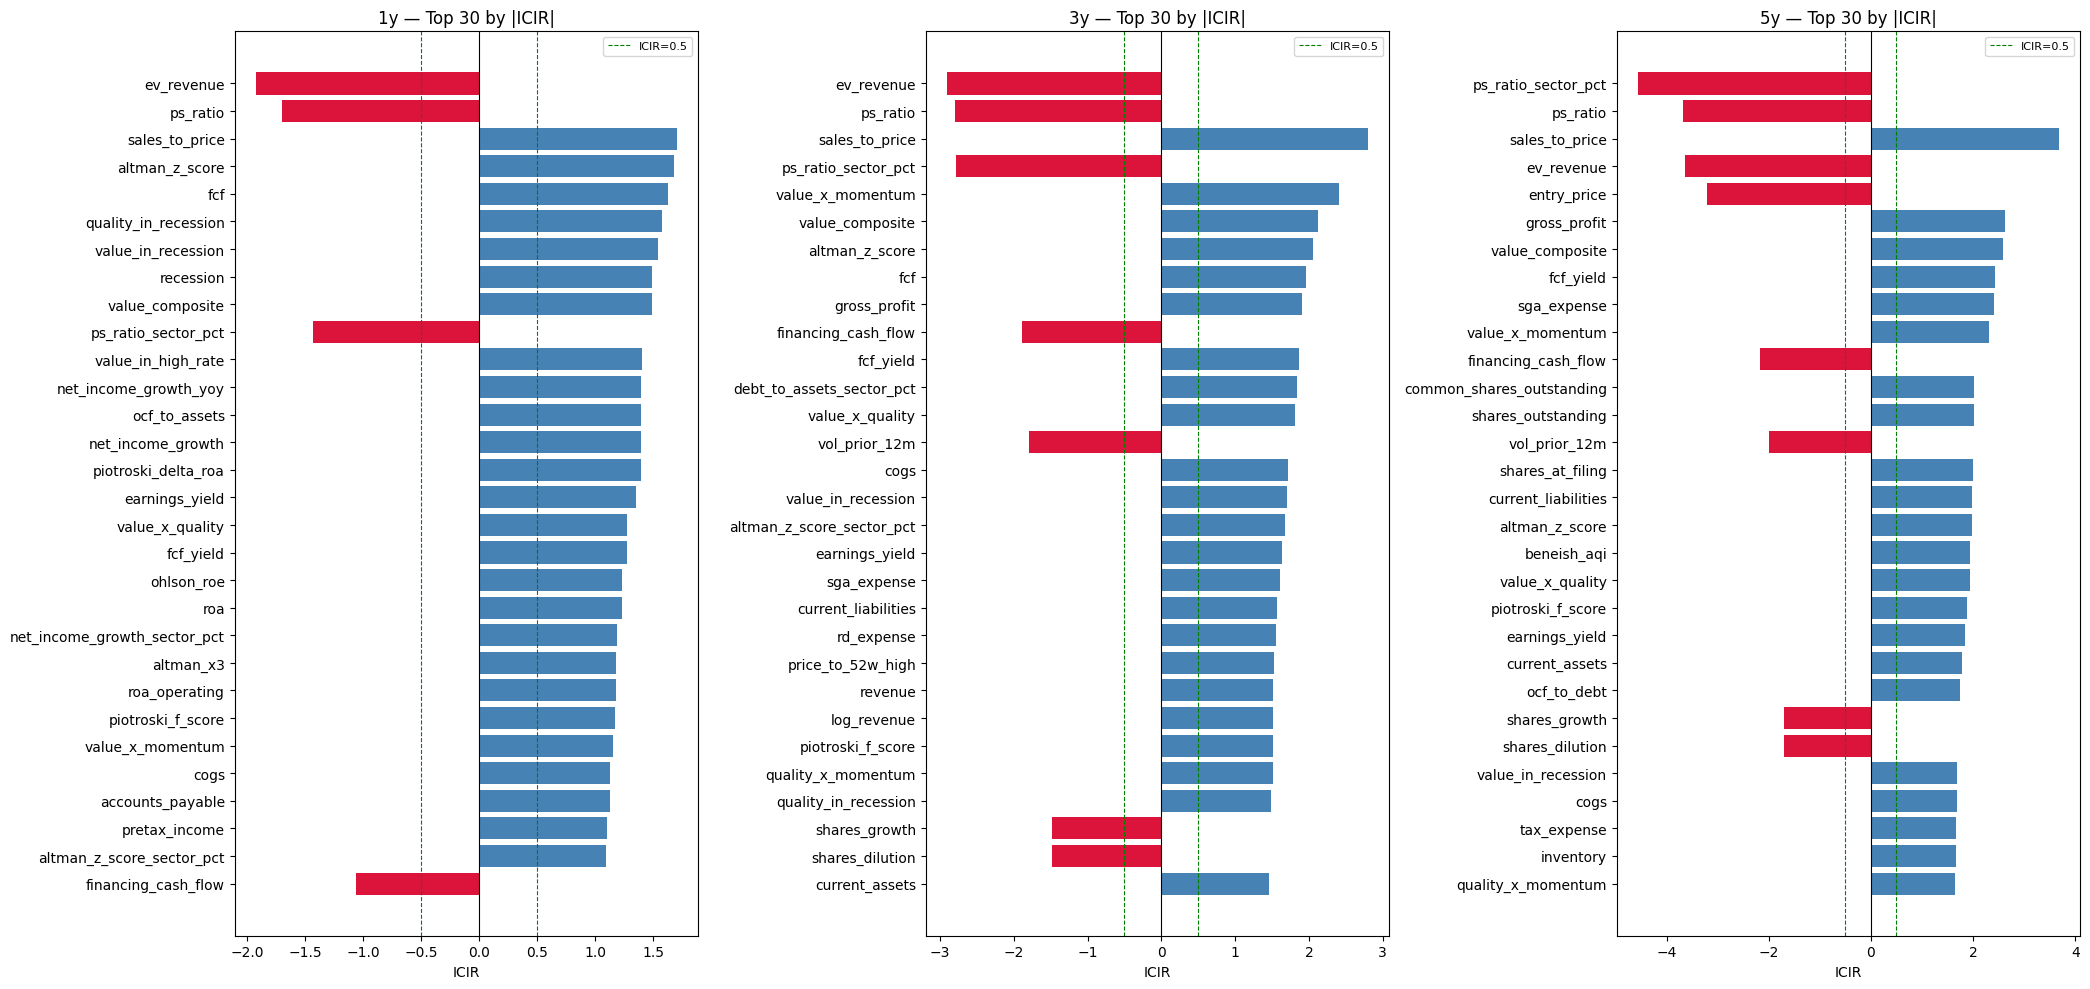

In [3]:
fig, axes = plt.subplots(1, len(dfs), figsize=(7 * len(dfs), 10))
if len(dfs) == 1:
    axes = [axes]

for ax, (h, df) in zip(axes, dfs.items()):
    if 'icir' not in df.columns:
        continue
    top = df.sort_values('icir', key=abs, ascending=False).head(30)
    colors = ['steelblue' if v > 0 else 'crimson' for v in top['icir']]
    ax.barh(top['feature'][::-1], top['icir'][::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(0.5, color='green', linestyle='--', linewidth=0.8, label='ICIR=0.5')
    ax.axvline(-0.5, color='green', linestyle='--', linewidth=0.8)
    ax.set_title(f'{h} — Top 30 by |ICIR|')
    ax.set_xlabel('ICIR')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3 — IC stability (pct_positive_ic) vs mean_ic scatter

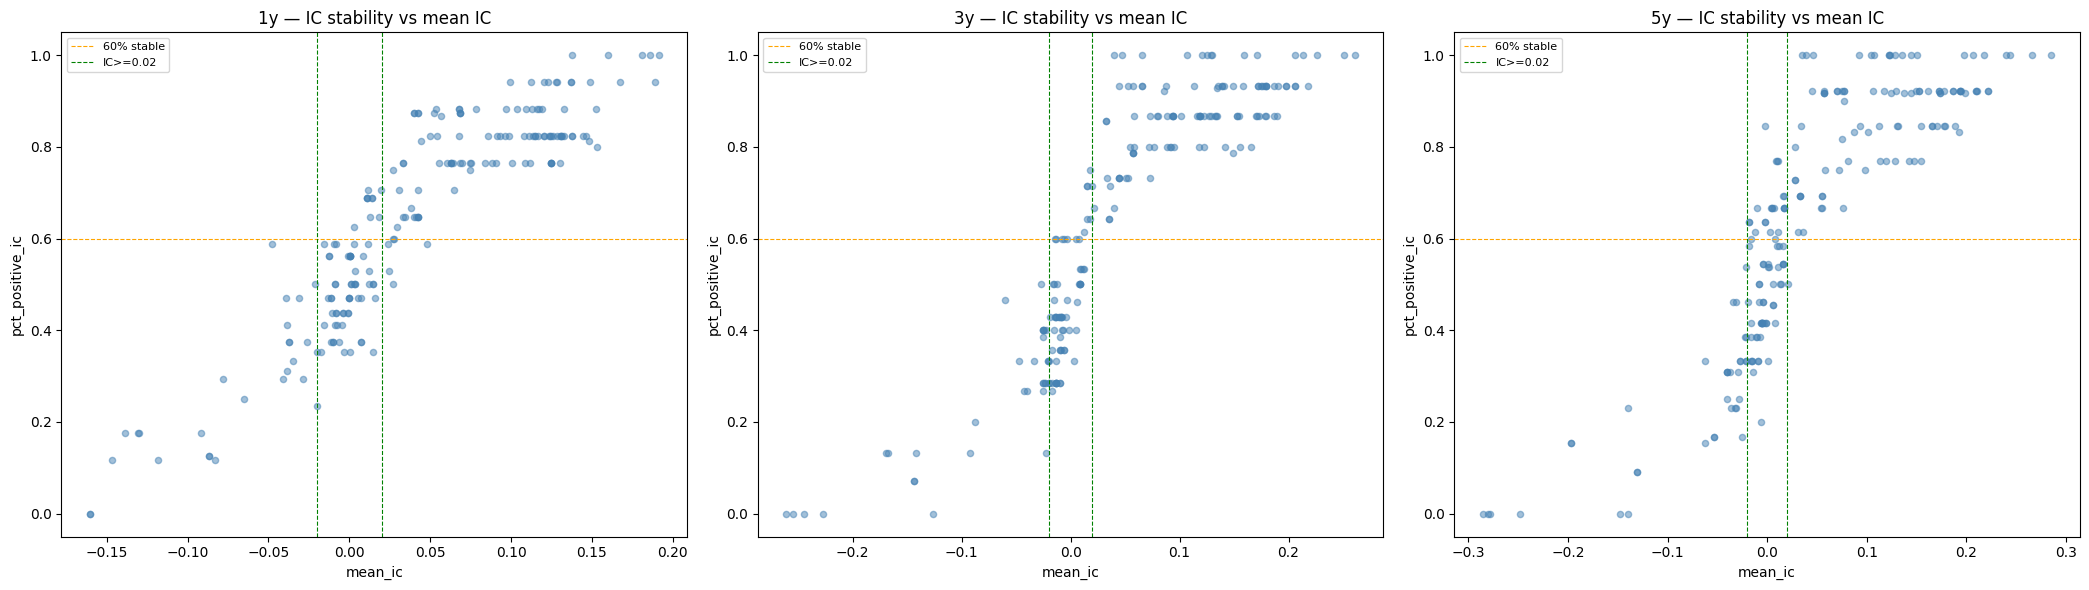

In [4]:
fig, axes = plt.subplots(1, len(dfs), figsize=(7 * len(dfs), 6))
if len(dfs) == 1:
    axes = [axes]

for ax, (h, df) in zip(axes, dfs.items()):
    if 'mean_ic' not in df.columns or 'pct_positive_ic' not in df.columns:
        continue
    ax.scatter(df['mean_ic'], df['pct_positive_ic'], alpha=0.5, s=20, color='steelblue')
    ax.axhline(0.60, linestyle='--', color='orange', linewidth=0.8, label='60% stable')
    ax.axvline(0.02, linestyle='--', color='green', linewidth=0.8, label='IC>=0.02')
    ax.axvline(-0.02, linestyle='--', color='green', linewidth=0.8)
    ax.set_title(f'{h} — IC stability vs mean IC')
    ax.set_xlabel('mean_ic')
    ax.set_ylabel('pct_positive_ic')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Feature overlap across horizons

In [5]:
import json

feat_sets = {}
for h in horizons:
    p = ROOT / 'models' / f'feature_sets_{h}.json'
    if p.exists():
        with open(p) as f:
            feat_sets[h] = set(json.load(f)['features'])
        print(f'{h}: {len(feat_sets[h])} selected features')

if len(feat_sets) == 3:
    shared_all = feat_sets['1y'] & feat_sets['3y'] & feat_sets['5y']
    print(f'\nFeatures in ALL three horizons: {len(shared_all)}')
    for f in sorted(shared_all):
        print(f'  {f}')

1y: 46 selected features
3y: 47 selected features
5y: 46 selected features

Features in ALL three horizons: 29
  alpha_composite
  alpha_fraud_risk
  alpha_quality
  alpha_value
  altman_z_score
  altman_z_score_sector_pct
  asset_turnover
  book_to_market
  data_confidence
  debt_to_assets_sector_pct
  earnings_yield
  fcf_yield
  financing_cashflow_to_assets
  gross_profit_to_assets
  ml_1y
  ml_3y
  ml_5y
  ocf_to_assets
  operating_margin_sector_pct
  pb_ratio_sector_pct
  piotroski_f_score_9
  piotroski_ocf_pos
  piotroski_shares_ok
  ps_ratio_sector_pct
  quarterly_positive_rev_frac
  roa_sector_pct
  small_x_quality
  value_composite
  value_x_momentum


## 5 — Feature selection summary (IC / ICIR / PSI)

In [6]:
summary_path = ROOT / 'reports' / 'feature_selection_summary.csv'
if summary_path.exists():
    sel = pd.read_csv(summary_path)
    print(f'feature_selection_summary.csv: {len(sel)} rows')
    print(sel.groupby(['horizon', 'selected']).size().unstack(fill_value=0))
    
    for h, grp in sel.groupby('horizon'):
        selected = grp[grp['selected'] == True]
        print(f'\n{h} selected features (sorted by |ICIR|):')
        top = selected.sort_values('icir', key=abs, ascending=False)
        print(top[['feature', 'mean_ic', 'icir', 'psi_train_vs_test']].head(20).to_string(index=False))

feature_selection_summary.csv: 645 rows
selected  False  True 
horizon               
1y          170     46
3y          169     47
5y          167     46

1y selected features (sorted by |ICIR|):
                  feature   mean_ic      icir  psi_train_vs_test
                    ml_1y  0.335414  3.350128           0.051755
                    ml_5y  0.269655  2.641513           0.013442
                    ml_3y  0.294813  2.518801           0.033799
         alpha_fraud_risk  0.242212  2.395581           0.005394
               ev_revenue -0.205623 -2.177701           0.079714
      ps_ratio_sector_pct -0.172814 -1.990682           0.001537
altman_z_score_sector_pct  0.108027  1.904759           0.000893
           altman_z_score  0.124775  1.866494           0.092029
              alpha_value  0.147226  1.821593           0.023609
          alpha_composite  0.183782  1.749772           0.013179
           ocf_growth_yoy  0.055605  1.689301           0.020274
          data_confiden